In [81]:
import importlib
import pandas as pd
import analysis_functions as af
import analysis_functions_behv as af_b
import preprocess_behav2p as preprocess
import visualize as viz
importlib.reload(af_b)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
from scipy.io import loadmat
from scipy.ndimage import uniform_filter1d
import os
import pickle
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter1d
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
import pandas as pd
from io_utils import save_pickle, load_pickle
import openpyxl

Summary Plot

In [ ]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record_BY.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
neuropil_factor = 0.1
tri_perc = 1
ani_range = [2,10,13]
for ani in ani_range:
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

In [170]:
gr2_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_2'])[:,20]]) for ani in data]
gr1_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_1'])[:,20]]) for ani in data]
reward_loc = [np.mean(data[ani]['position'][np.array(data[ani]['reward_indices'])[:,20]]) for ani in data]

In [ ]:
# get baseline-subtracted pupil
baseline_frames = slice(0,10)  # 1s pre-event window (onset at frame 19)
for ani in ani_range:
    if data[ani].get('pupil_rel') is None:
        continue
    data[ani]['pupil_rel_bs'] = {}
    for grat in data[ani]['pupil_rel']:
        epochs = data[ani]['pupil_rel'][grat].copy().astype(float)
        bad = np.mean(np.isnan(epochs), axis=1) > 0.5
        epochs[bad] = np.nan  # remove the trials that contains more than 50% NaN
        baseline_mean = np.nanmean(epochs[:, baseline_frames], axis=1, keepdims=True)
        data[ani]['pupil_rel_bs'][grat] = epochs - baseline_mean

In [231]:
ani = 13

s = data[ani]['speed']
s_sm = gaussian_filter1d(s, sigma=0.7)
s_session_baseline = np.nanpercentile(s_sm, 50)
speed = s_sm - s_session_baseline

p = data[ani]["pupil"].to_numpy().astype(float)
p_sm = gaussian_filter1d(p, sigma=0.7)
p_session_baseline = np.nanpercentile(p_sm, 50)
pupil = p_sm - p_session_baseline

lick_onsets = data[ani]['aligned_data']['Lick'].to_numpy()
lick_rate = []
rolling_window_frames = 7
lick_count_rolling_sum = pd.Series(lick_onsets).rolling(window=rolling_window_frames,min_periods=1).sum()  # rolling sum over 7 frames
lick_rate = np.array(lick_count_rolling_sum)*7.5/rolling_window_frames # Convert to licks/sec (7.5 fps, 7 frames rolling window)

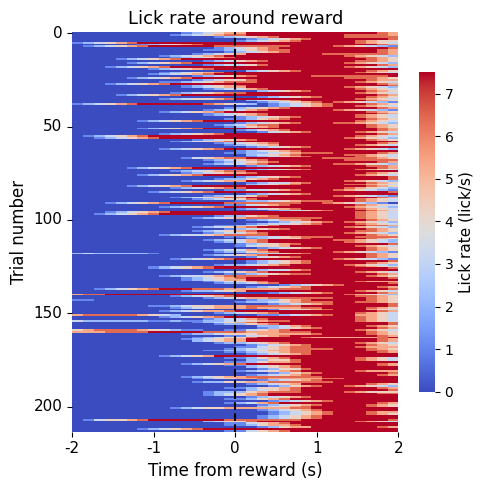

In [232]:
bin_size = 1
bins = np.arange(0, 30 + bin_size, bin_size)
n_bins = len(bins) - 1
lick_rate_matrix = lick_rate[data[ani]['reward_indices']][:,5:35]

fig, ax = plt.subplots(figsize=(5, 5))

vmin, vmax = np.nanpercentile(lick_rate_matrix, [2, 98])
hm = sns.heatmap(lick_rate_matrix, ax=ax, cmap='coolwarm', vmin=vmin, vmax=vmax,
                  cbar_kws={'label': 'Lick rate (lick/s)', 'shrink': 0.8})
hm.collections[0].colorbar.ax.tick_params(labelsize=10)
hm.collections[0].colorbar.set_label('Lick rate (lick/s)', fontsize=11)

# set y-ticks every 50 trials (0, 50, 100, ...)
n_trials = lick_rate_matrix.shape[0]
y_ticks = np.arange(0, max(1, n_trials), 50)
y_labels = [str(int(y)) for y in y_ticks]
ax.set_yticks(y_ticks + 0.5)
ax.set_yticklabels(y_labels)
ax.set_ylabel('Trial number', fontsize=12)

# set x-ticks every 7.5 bins -> every 1s
n_bins = lick_rate_matrix.shape[1]
ax.set_xticks([0, 7.5, 15, 22.5, 30])
ax.set_xticklabels(['-2', '-1', '0', '1', '2'], rotation=0)
ax.set_xlabel('Time from reward (s)', fontsize=12)
ax.axvline(x=15, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Lick rate around reward', fontsize=13)
ax.tick_params(axis='both', labelsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

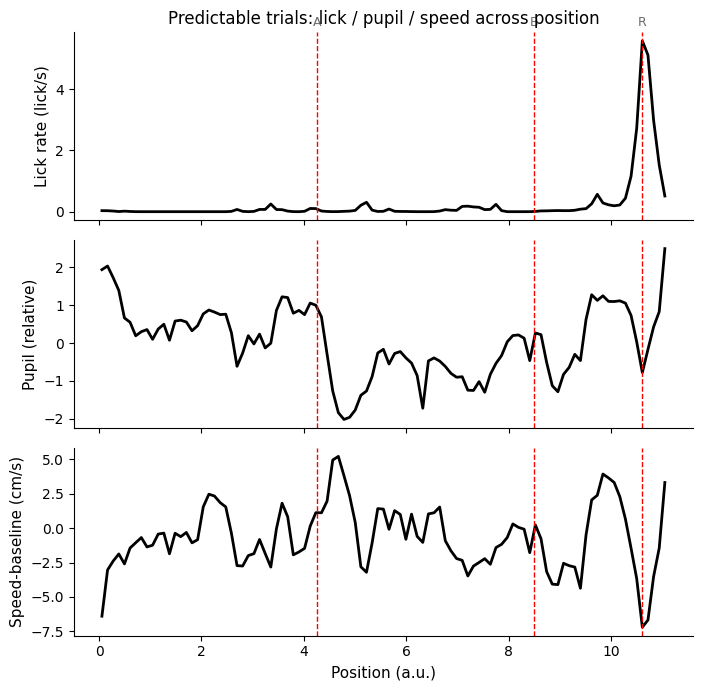

In [239]:
animals = [13]
bin_size = 0.11
max_pos = max(np.nanmax(data[a]['position']) for a in animals)
bins = np.arange(0, max_pos + bin_size, bin_size)
n_bins = len(bins) - 1
bin_centers = (bins[:-1] + bins[1:]) / 2

lick_matrix = np.full((len(animals), n_bins), np.nan)
speed_matrix = np.full((len(animals), n_bins), np.nan)
pupil_matrix = np.full((len(animals), n_bins), np.nan)


for i,ani in enumerate(animals):
    # Predicted Trials Mask
    pred_mask = np.zeros(len(data[ani]['pupil']), dtype=bool)
    trial_starts = data[ani]['trial_start_indices']
    pred_trials = data[ani]['pred_trials']
    for t in pred_trials:
        start = trial_starts[t]
        if t < len(trial_starts) - 1:
            end = trial_starts[t+1]
        else:
            end = len(data[ani]['pupil']) 
        pred_mask[start:end] = True

    pos = data[ani]['position']

    for b in range(n_bins):
        in_bin = (pos >= bins[b]) & (pos < bins[b+1]) & pred_mask
        # bins with no samples are left as NaN (rather than 0) so a position bin
        # that's simply never visited at this resolution doesn't get plotted as
        # "speed/pupil = 0", which would otherwise show up as a spurious dip
        if np.sum(in_bin) > 0:
            lick_matrix[i, b] = np.nanmean(lick_rate[in_bin])
            speed_matrix[i,b] = np.nanmean(speed[in_bin])
            pupil_matrix[i,b] = np.nanmean(pupil[in_bin])

lick_trace = np.nanmean(lick_matrix, axis=0)
pupil_trace = np.nanmean(pupil_matrix, axis=0)
speed_trace = np.nanmean(speed_matrix, axis=0)

def fill_and_smooth(trace, sigma=0.5):
    # gaussian_filter1d can't handle NaNs, so linearly interpolate across any
    # never-visited bins before smoothing
    filled = pd.Series(trace).interpolate(limit_direction='both').to_numpy()
    return gaussian_filter1d(filled, sigma=sigma)

lick_smooth = fill_and_smooth(lick_trace)
pupil_smooth = fill_and_smooth(pupil_trace)
speed_smooth = fill_and_smooth(speed_trace)

# only 2 stimuli (gr_1, gr_2) in this task, positions taken from the gr1_loc/gr2_loc/reward_loc
# computed above, in the same arbitrary units as data[ani]['position']
grat1_pos = np.mean(gr1_loc)
grat2_pos = np.mean(gr2_loc)
reward_pos = np.mean(reward_loc)

fig,axs = plt.subplots(3,1,figsize = (7,7), sharex=True)

panels = [(axs[0], lick_smooth, "Lick rate (lick/s)"),
          (axs[1], pupil_smooth, "Pupil (relative)"),
          (axs[2], speed_smooth, "Speed-baseline (cm/s)")]

for a, trace, ylabel in panels:
    a.plot(bin_centers, trace, lw=2, color='black')
    a.axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
    a.axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
    a.axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
    a.spines['right'].set_visible(False)
    a.spines['top'].set_visible(False)
    a.set_ylabel(ylabel, fontsize=11)
    a.tick_params(axis='both', labelsize=10)

for label, xpos in [('A', grat1_pos), ('B', grat2_pos), ('R', reward_pos)]:
    axs[0].text(xpos, 1.02, label, transform=axs[0].get_xaxis_transform(),
                ha='center', va='bottom', fontsize=9, color='dimgrey')

axs[0].set_title("Predictable trials: lick / pupil / speed across position", fontsize=12)
axs[2].set_xlabel("Position (a.u.)", fontsize=11)

plt.tight_layout()
# plt.savefig("Behaviour across positions.svg", format="svg")
plt.show()

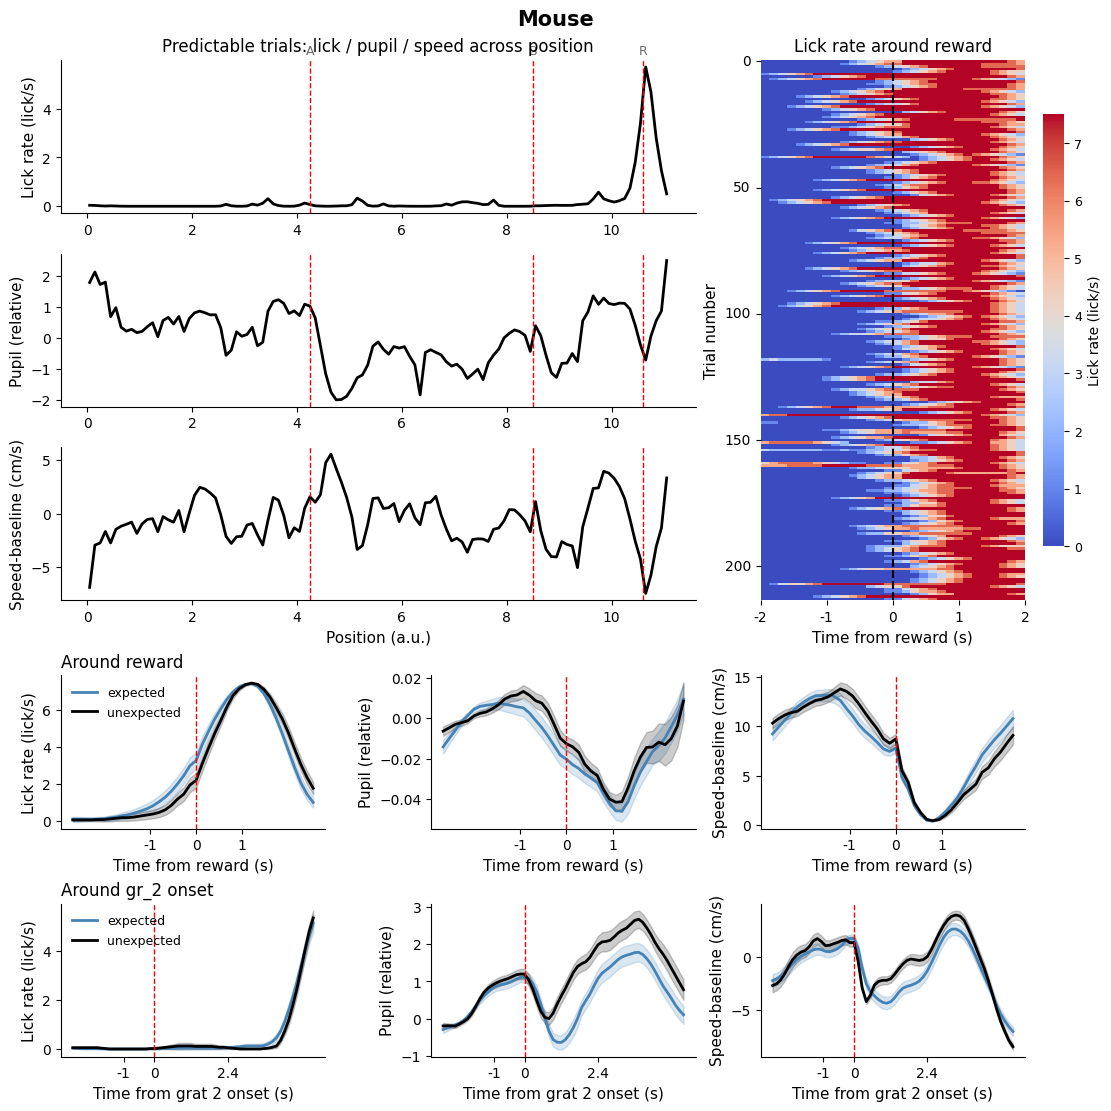

In [236]:
mosaic = [    
    ["A", "A", "A", "A", "D", "D"],
    ["B", "B", "B", "B", "D", "D"],
    ["C", "C", "C", "C", "D", "D"],
    ["E", "E", "F", "F", "G", "G"],
    ["H", "H", "I", "I", "J", "J"],
    ]

fig, ax = plt.subplot_mosaic(mosaic, figsize=(11, 11), constrained_layout=True,)   # good default spacing
pred_trials = np.unique(data[ani]['pred_trials'])
unpred_trials = data[ani]['unpred_trials']['gr_2']
name = 'Mouse'

# ----- Lick rate / Pupil / Speed across position (predictable trials) -----
for key, trace, ylabel in [("A", lick_smooth, "Lick rate (lick/s)"),
                           ("B", pupil_smooth, "Pupil (relative)"),
                           ("C", speed_smooth, "Speed-baseline (cm/s)")]:
    ax[key].plot(bin_centers, trace, lw=2, color='black')
    ax[key].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
    ax[key].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
    ax[key].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
    ax[key].spines['right'].set_visible(False)
    ax[key].spines['top'].set_visible(False)
    ax[key].set_ylabel(ylabel, fontsize=11)
    ax[key].tick_params(axis='both', labelsize=10)

for label, xpos in [('A', grat1_pos), ('B', grat2_pos), ('R', reward_pos)]:
    ax["A"].text(xpos, 1.02, label, transform=ax["A"].get_xaxis_transform(),
                 ha='center', va='bottom', fontsize=9, color='dimgrey')

ax["A"].set_title("Predictable trials: lick / pupil / speed across position", fontsize=12)
ax["C"].set_xlabel("Position (a.u.)", fontsize=11)

# ----- D: lick-rate heatmap around reward, across trials -----
vmin, vmax = np.nanpercentile(lick_rate_matrix, [2, 98])
hm = sns.heatmap(lick_rate_matrix, ax=ax["D"], cmap='coolwarm', vmin=vmin, vmax=vmax,
                  cbar_kws={'label': 'Lick rate (lick/s)', 'shrink': 0.8})
hm.collections[0].colorbar.ax.tick_params(labelsize=9)
hm.collections[0].colorbar.set_label('Lick rate (lick/s)', fontsize=10)
n_trials = lick_rate_matrix.shape[0]
y_ticks = np.arange(0, max(1, n_trials), 50)
y_labels = [str(int(y)) for y in y_ticks]
ax["D"].set_yticks(y_ticks + 0.5)
ax["D"].set_yticklabels(y_labels)
ax["D"].set_ylabel('Trial number', fontsize=11)
n_bins = lick_rate_matrix.shape[1]
ax["D"].set_xticks([0, 7.5, 15, 22.5, 30])
ax["D"].set_xticklabels(['-2', '-1', '0', '1', '2'], rotation=0)
ax["D"].set_xlabel('Time from reward (s)', fontsize=11)
ax["D"].axvline(x=15, color='black', linestyle='--', linewidth=1.5)
ax["D"].set_title('Lick rate around reward', fontsize=12)
ax["D"].tick_params(axis='both', labelsize=10)
ax["D"].spines['top'].set_visible(False)
ax["D"].spines['right'].set_visible(False)

# ----- E/F/G: near reward, expected (all trials) vs unexpected (X) trials -----
# lick rate is a whole-session trace indexed via reward_indices; pupil/speed are
# already trial x frame matrices (baseline-subtracted pupil, cm/s speed) keyed by 'rew'
reward_traces = {
    "E": (lick_rate[data[ani]['reward_indices']], 'Lick rate (lick/s)'),
    "F": (data[ani]['pupil_rel_bs']['rew'], 'Pupil (relative)'),
    "G": (data[ani]['speed_cm_s']['rew'], 'Speed-baseline (cm/s)'),
}
for key, (mat, ylabel) in reward_traces.items():
    t_frames = mat.shape[1]
    viz.plot_shaded_error(ax[key], np.arange(t_frames), mat,
                          color='steelblue', label='expected' if key == 'E' else None, alpha=0.2)
    viz.plot_shaded_error(ax[key], np.arange(t_frames), mat[unpred_trials, :],
                          color='black', label='unexpected' if key == 'E' else None, alpha=0.2)
    ax[key].axvline(x=20, color='red', linestyle='--', linewidth=1)
    ax[key].set_ylabel(ylabel, fontsize=11)
    ax[key].set_xlabel('Time from reward (s)', fontsize=11)
    ax[key].set_xticks([12.5, 20, 27.5])
    ax[key].set_xticklabels(['-1', '0', '1'])
    ax[key].tick_params(axis='both', labelsize=10)
    ax[key].spines['right'].set_visible(False)
    ax[key].spines['top'].set_visible(False)
ax['E'].legend(frameon=False, fontsize=9)
ax['E'].set_title('Around reward', fontsize=12, loc='left')

# ----- H/I/J: near gr_2 onset, expected (all gr_2 trials) vs unexpected (X) trials -----
grat2_traces = {
    "H": (lick_rate[data[ani]['grating_indices']['gr_2']], 'Lick rate (lick/s)'),
    "I": (data[ani]['pupil_rel_bs']['gr_2'], 'Pupil (relative)'),
    "J": (data[ani]['speed_cm_s']['gr_2'], 'Speed-baseline (cm/s)'),
}
for key, (mat, ylabel) in grat2_traces.items():
    t_frames = mat.shape[1]
    viz.plot_shaded_error(ax[key], np.arange(t_frames), mat,
                          color='steelblue', label='expected' if key == 'H' else None, alpha=0.2)
    viz.plot_shaded_error(ax[key], np.arange(t_frames), mat[unpred_trials, :],
                          color='black', label='unexpected' if key == 'H' else None, alpha=0.2)
    ax[key].axvline(x=20, color='red', linestyle='--', linewidth=1)
    ax[key].set_ylabel(ylabel, fontsize=11)
    ax[key].set_xlabel('Time from grat 2 onset (s)', fontsize=11)
    ax[key].set_xticks([12.5, 20, 38])
    ax[key].set_xticklabels(['-1', '0', '2.4'])
    ax[key].tick_params(axis='both', labelsize=10)
    ax[key].spines['right'].set_visible(False)
    ax[key].spines['top'].set_visible(False)
ax['H'].legend(frameon=False, fontsize=9)
ax['H'].set_title('Around gr_2 onset', fontsize=12, loc='left')

fig.suptitle(name, fontsize=15, fontweight='bold')
fig.savefig(os.path.join(table.iloc[ani][2], "Behavior Summary.png"), dpi=300, bbox_inches="tight")

plt.show()